# Precio segun el genero del juego

## Imports y carga inicial

In [288]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [289]:
applications = pd.read_csv("data/applications.csv")
genres = pd.read_csv("data-cleaned/genres_clean.csv")
application_genres = pd.read_csv("data/application_genres.csv")

/tmp/ipykernel_574040/1979061772.py:1: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv("data/applications.csv")


## Inspeccion inicial

In [290]:
print(applications.shape)
print(genres.shape)
print(application_genres.shape)

display(applications.head())
display(genres.head())
display(application_genres.head())

(239664, 30)
(154, 2)
(587515, 2)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,88.0,161854.0,True,True,True,999.0,999.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,6633.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,79.0,4308.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,2338.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,22793.0,True,True,True,499.0,499.0,0.0,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


,genre_id,genre_name
0,1,Adventure
1,2,MMO
2,3,Indie
3,4,Strategy
4,5,Strategy


,appid,genre_id
0,10,122
1,20,122
2,30,122
3,40,122
4,50,122


In [291]:
for col in applications.columns:
    print(col)

appid
name
type
is_free
release_date
required_age
short_description
supported_languages
header_image
background
metacritic_score
recommendations_total
mat_supports_windows
mat_supports_mac
mat_supports_linux
mat_initial_price
mat_final_price
mat_discount_percent
mat_currency
mat_achievement_count
mat_pc_os_min
mat_pc_processor_min
mat_pc_memory_min
mat_pc_graphics_min
mat_pc_os_rec
mat_pc_processor_rec
mat_pc_memory_rec
mat_pc_graphics_rec
created_at
updated_at


In [292]:
# Limpieza de columnas
applications = applications.drop(
    columns=[
        # "appid",
        # "name",
        # "type",
        # "is_free",
        "release_date",
        "required_age",
        "short_description",
        "supported_languages",
        "header_image",
        "background",
        "metacritic_score", # Esta lleno de nulos
        "recommendations_total", # No creo que valga la pena

        # Hay que ver cual de los dos
        # "mat_initial_price",
        "mat_final_price",

        # Todos estos son puros requerimientos
        # es basura (o tal vez no?)
        "mat_supports_windows",
        "mat_supports_mac",
        "mat_supports_linux",
        "mat_discount_percent",
        "mat_currency",
        "mat_achievement_count",
        "mat_pc_os_min",
        "mat_pc_processor_min",
        "mat_pc_memory_min",
        "mat_pc_graphics_min",
        "mat_pc_os_rec",
        "mat_pc_processor_rec",
        "mat_pc_memory_rec",
        "mat_pc_graphics_rec",
        "created_at",
        "updated_at",
    ]
)

In [293]:
nulls = (
    applications
    .isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(nulls[nulls > 0])

mat_initial_price    39.530760
type                  1.112808
name                  0.001669
dtype: float64

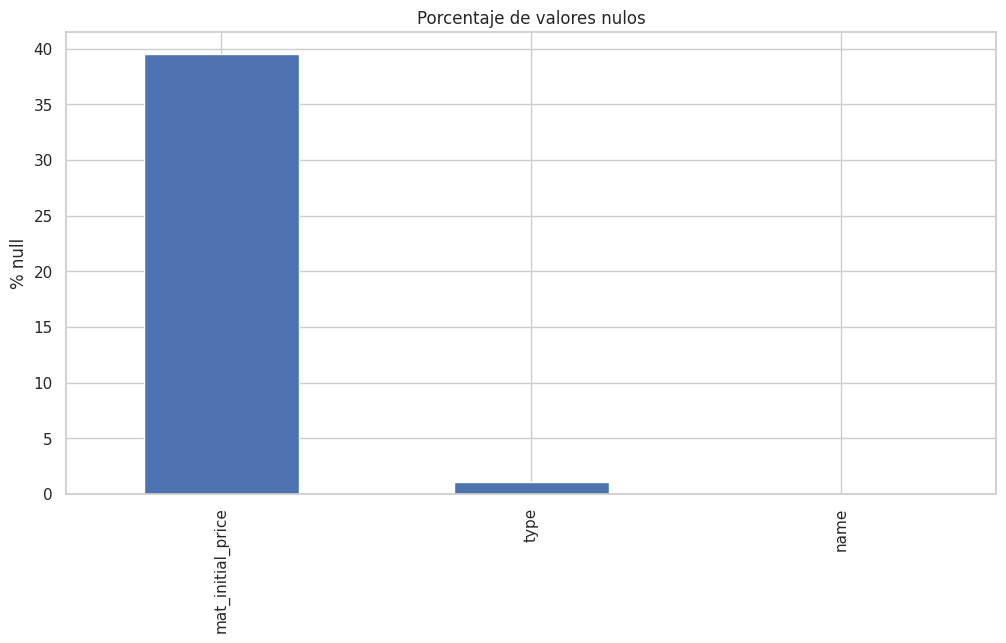

In [294]:
plt.figure(figsize=(12,6))

nulls[nulls > 0].plot(kind="bar")

plt.title("Porcentaje de valores nulos")
plt.ylabel("% null")
plt.show()

## Columnas de precio

In [295]:
price_cols = [c for c in applications.columns if "price" in c.lower()]
print(price_cols)

['mat_initial_price']


## Limpieza de datos

In [296]:
applications["price"] = applications["mat_initial_price"]
applications = applications.drop(columns=["mat_initial_price"])
applications["price"] = pd.to_numeric(
    applications["price"],
    errors="coerce"
)

applications = applications.dropna(subset=["price"])

applications = applications[
    applications["price"] >= 0
]

## Distribucion del precio

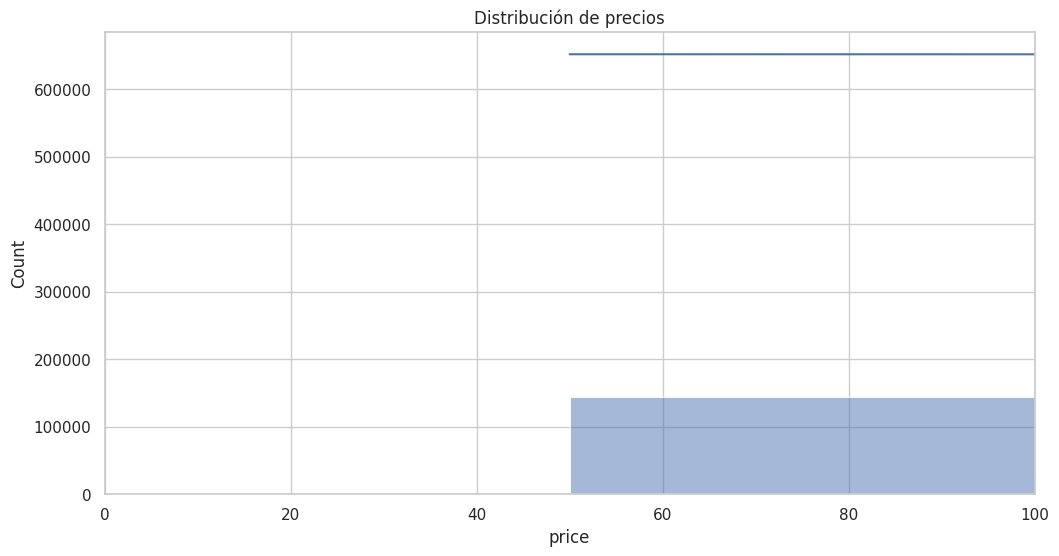

In [297]:
applications["price"].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

plt.figure(figsize=(12,6))

sns.histplot(
    applications["price"],
    bins=100,
    kde=True
)

plt.title("Distribución de precios")
plt.xlim(0, 100)
plt.show()

## Analizar skewness

In [298]:
print("Skewness:", applications["price"].skew())
print("Kurtosis:", applications["price"].kurtosis())

Skewness: 58.19724891352271
Kurtosis: 4185.577867340242


## Log-transform candidate

In [299]:
applications["log_price"] = np.log1p(applications["price"])

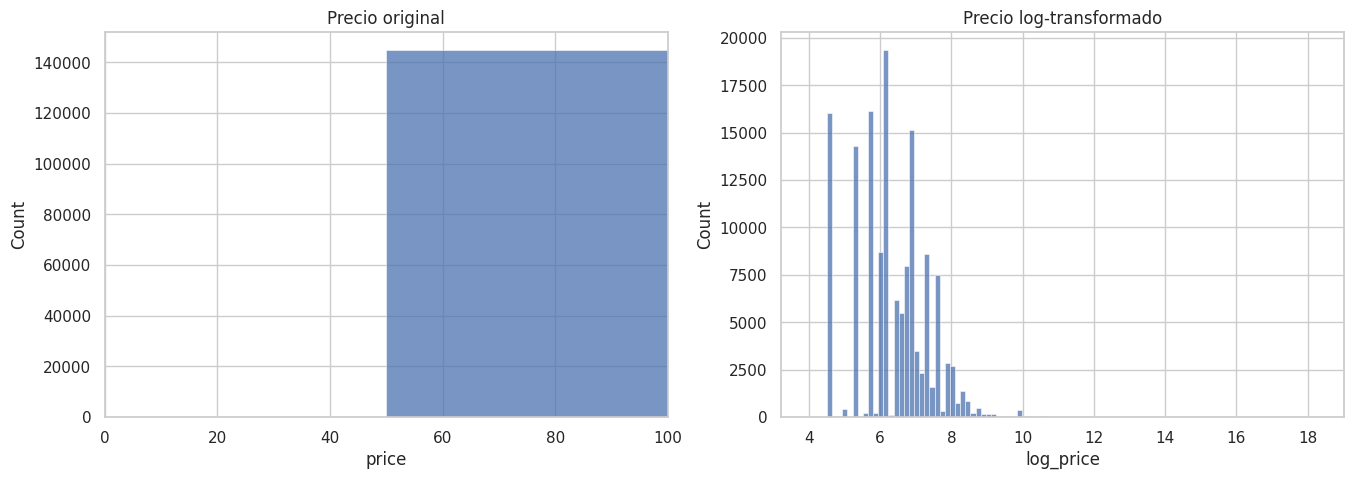

In [300]:
fig, ax = plt.subplots(1,2, figsize=(16,5))

sns.histplot(applications["price"], bins=100, ax=ax[0])
ax[0].set_title("Precio original")
ax[0].set_xlim(0,100)

sns.histplot(applications["log_price"], bins=100, ax=ax[1])
ax[1].set_title("Precio log-transformado")

plt.show()

## Relacion con generos

### Revisar tablas relacionales

In [301]:
display(genres.head())
display(application_genres.head())

,genre_id,genre_name
0,1,Adventure
1,2,MMO
2,3,Indie
3,4,Strategy
4,5,Strategy


,appid,genre_id
0,10,122
1,20,122
2,30,122
3,40,122
4,50,122


### Join de generos

In [302]:
app_genres = (
    application_genres
    .merge(
        genres,
        on="genre_id",
        how="left"
    )
)
display(app_genres.head())

,appid,genre_id,genre_name
0,10,122,Action
1,20,122,Action
2,30,122,Action
3,40,122,Action
4,50,122,Action


### Agrupar generos por juego

In [303]:
genres_per_game = (
    app_genres
    .groupby("appid")["genre_name"]
    .apply(list)
    .reset_index()
)

### Merge final

In [304]:
df = applications.merge(
    genres_per_game,
    on="appid",
    how="left"
)

### Revisar sparsity de generos

In [305]:
genre_counts = (
    app_genres["genre_name"]
    .value_counts()
)

display(genre_counts)

genre_name
Indie                    134192
Action                    84444
Casual                    77752
Adventure                 76028
Simulation                47945
RPG                       45939
Strategy                  43997
Free To Play              21821
Early Access              14731
Sports                     8601
Racing                     7541
MMO                        6076
Design & Illustration      3688
Web Publishing             2976
Utilities                  2078
Education                  1788
Game Development           1731
Animation & Modeling       1141
Violent                     861
Video Production            741
Software Training           651
Audio Production            634
Gore                        533
Movie                       494
Photo Editing               401
Sexual Content              292
Nudity                      272
Documentary                  56
Accounting                   35
Episodic                     31
Short                        

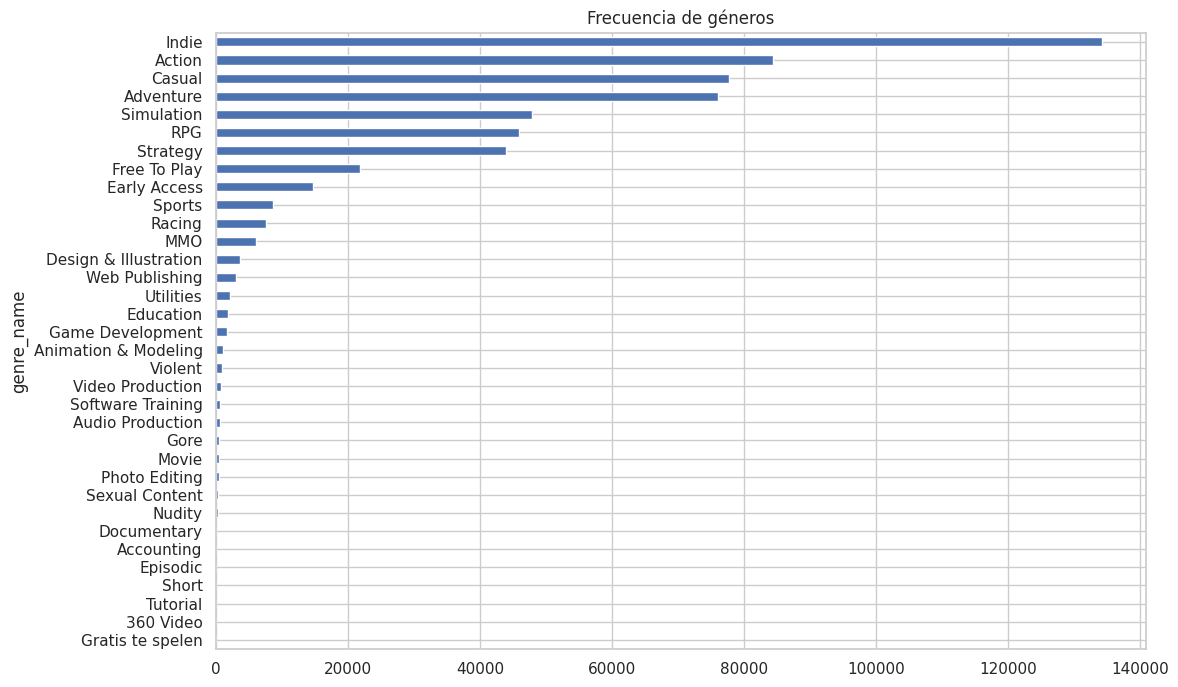

In [306]:
plt.figure(figsize=(12,8))

genre_counts.sort_values().plot(kind="barh")

plt.title("Frecuencia de géneros")
plt.show()

### Multi-label encoding

In [307]:
df["genre_name"] = df["genre_name"].apply(
    lambda x: x if isinstance(x, list) else []
)

mlb = MultiLabelBinarizer()

genre_matrix = pd.DataFrame(
    mlb.fit_transform(df["genre_name"]),
    columns=mlb.classes_,
    index=df.index
)

display(genre_matrix.head())

,360 Video,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,Education,Episodic,Free To Play,Game Development,Gore,Gratis te spelen,Indie,MMO,Movie,Nudity,Photo Editing,RPG,Racing,Sexual Content,Short,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Dataset modelable

In [308]:
model_df = pd.concat(
    [
        df[["appid", "price", "log_price"]],
        genre_matrix
    ],
    axis=1
)

## Visualizacion de relaciones

### Precio promedio por genero

In [309]:
genre_price_analysis = []

for genre in mlb.classes_:

    subset = model_df[model_df[genre] == 1]

    genre_price_analysis.append({
        "genre": genre,
        "count": len(subset),
        "mean_price": subset["price"].mean(),
        "median_price": subset["price"].median(),
        "std_price": subset["price"].std()
    })

genre_price_df = pd.DataFrame(genre_price_analysis)

genre_price_df = genre_price_df.sort_values(
    by="mean_price",
    ascending=False
)

display(genre_price_df)

,genre,count,mean_price,median_price,std_price
17,MMO,2795,43474.117352,999.0,1.313676e+06
25,Simulation,33444,33256.464478,699.0,9.847318e+05
26,Software Training,539,33080.005566,1499.0,7.107506e+05
2,Action,54198,31057.648862,499.0,1.096064e+06
22,Racing,5334,27171.330146,499.0,6.991746e+05
4,Animation & Modeling,887,21343.684329,1499.0,5.540610e+05
3,Adventure,47017,20106.759215,599.0,8.533064e+05
21,RPG,29921,19831.821664,699.0,7.900596e+05
27,Sports,6435,19790.441336,599.0,5.838292e+05
28,Strategy,29825,18000.915172,599.0,5.265255e+05


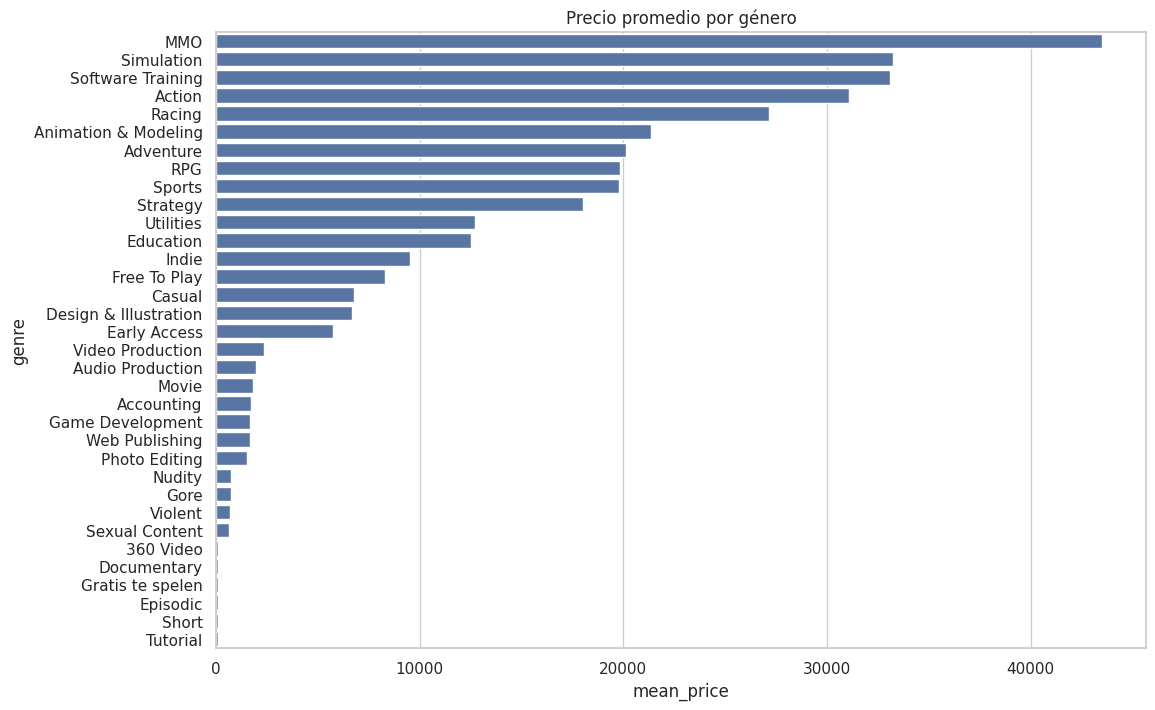

In [310]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=genre_price_df,
    y="genre",
    x="mean_price"
)

plt.title("Precio promedio por género")
plt.show()

### Boxplots por genero

In [311]:
long_df = []

for genre in mlb.classes_:

    subset = model_df[model_df[genre] == 1]

    tmp = pd.DataFrame({
        "genre": genre,
        "price": subset["price"]
    })

    long_df.append(tmp)

long_df = pd.concat(long_df)

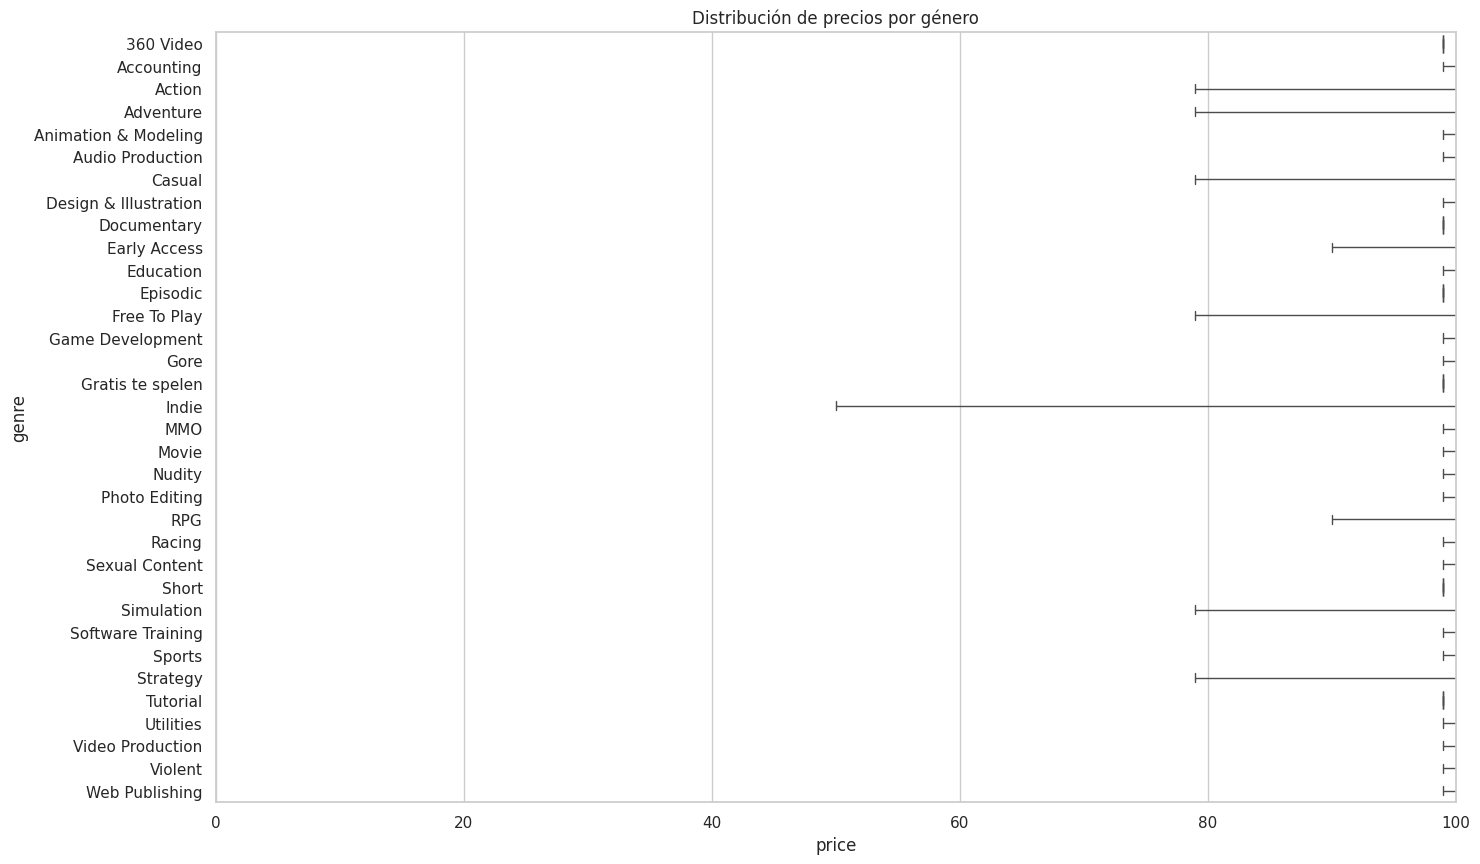

In [312]:
plt.figure(figsize=(16,10))

sns.boxplot(
    data=long_df,
    y="genre",
    x="price",
    showfliers=False
)

plt.xlim(0,100)

plt.title("Distribución de precios por género")
plt.show()

### Correlacion precio-genero

In [313]:
corrs = []

for genre in mlb.classes_:

    corr = model_df[[genre, "log_price"]].corr().iloc[0,1]

    corrs.append({
        "genre": genre,
        "correlation": corr
    })

corrs = pd.DataFrame(corrs)

display(
    corrs.sort_values(
        by="correlation",
        ascending=False
    )
)

,genre,correlation
7,Design & Illustration,0.123687
33,Web Publishing,0.115113
21,RPG,0.111452
25,Simulation,0.103396
17,MMO,0.077595
13,Game Development,0.073752
28,Strategy,0.071865
10,Education,0.067808
9,Early Access,0.066645
4,Animation & Modeling,0.056318


### Multicolinealidad entre generos

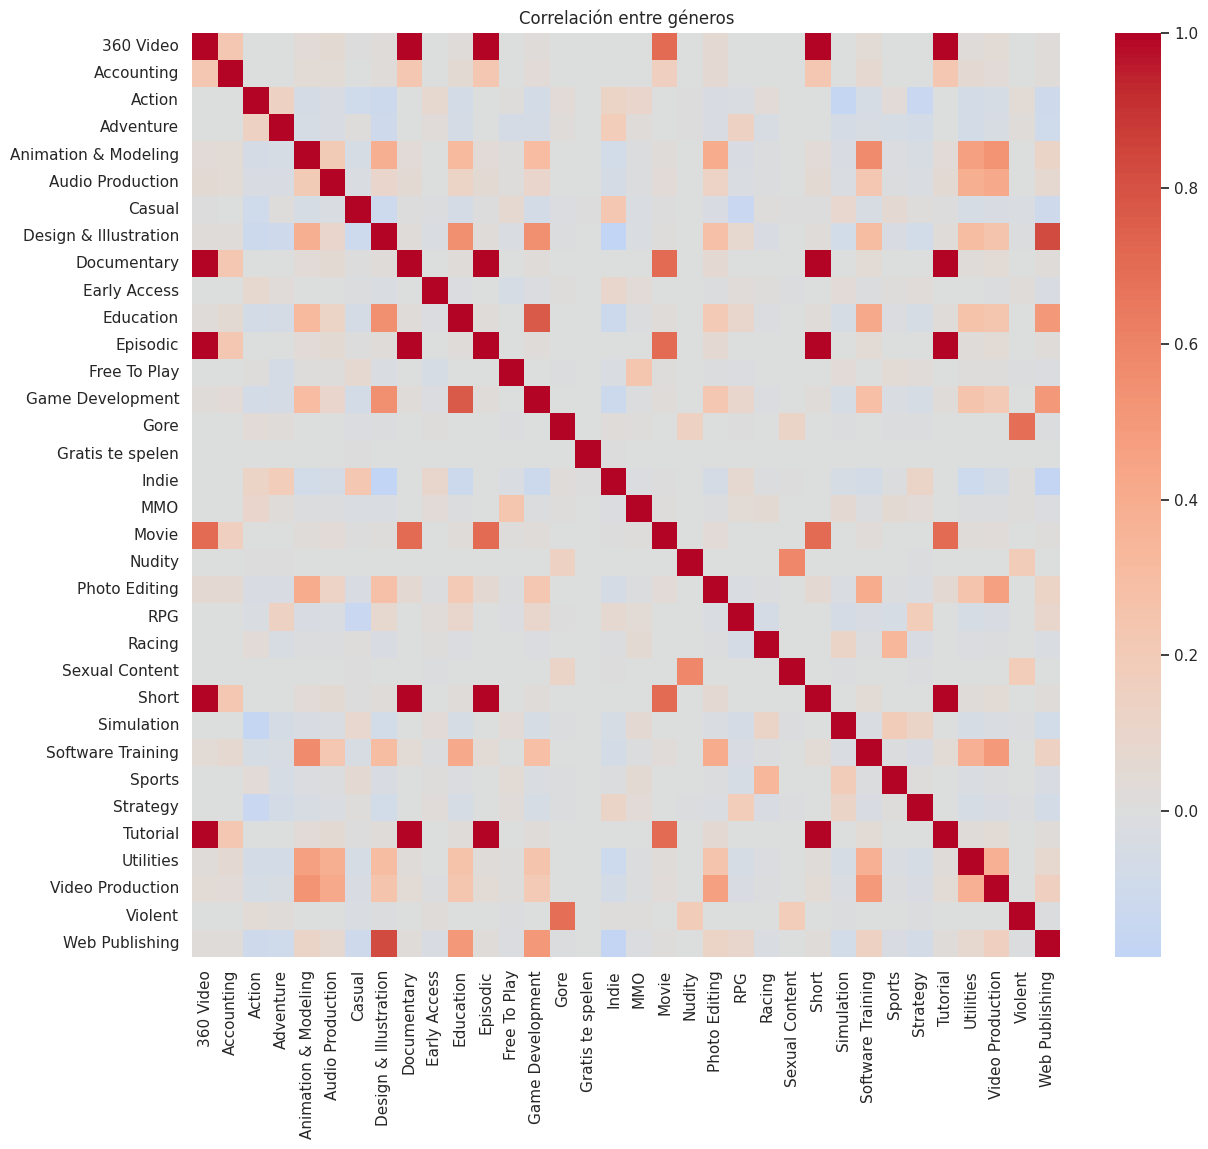

In [314]:
genre_corr = genre_matrix.corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    genre_corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre géneros")
plt.show()

### Juegos gratis vs pagos

In [315]:
# df["is_free"] = (df["price"] == 0).astype(int)

# print(df["is_free"].value_counts(normalize=True))

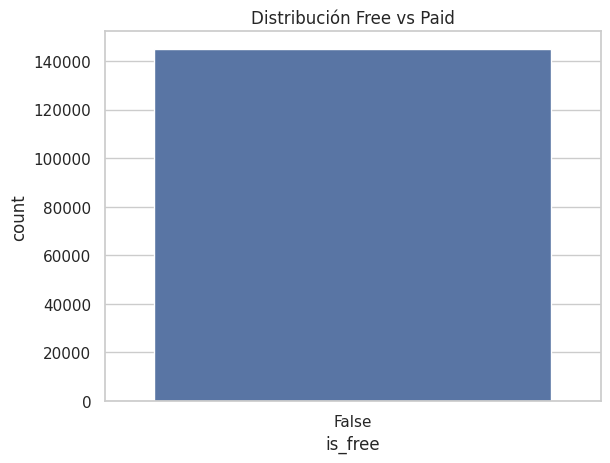

In [316]:
sns.countplot(data=df, x="is_free")
plt.title("Distribución Free vs Paid")
plt.show()

## Evaluacion rapida de regresion lineal

In [325]:
# X = genre_matrix
y = model_df["log_price"]
X = model_df.drop(columns=["price", "log_price"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

model = LinearRegression()

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R2:", r2_score(y_test, preds))

R2: 0.10153301264719916


## Interpretacion de coeficientes

In [318]:
coefficients = pd.DataFrame({
    "genre": X.columns,
    "coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="coefficient",
    ascending=False
)

display(coefficients)

,genre,coefficient
19,Movie,1.563423e+00
18,MMO,4.699839e-01
8,Design & Illustration,4.421188e-01
5,Animation & Modeling,3.974137e-01
6,Audio Production,3.786391e-01
34,Web Publishing,3.581618e-01
10,Early Access,3.024923e-01
2,Accounting,2.967654e-01
26,Simulation,2.819606e-01
29,Strategy,1.953922e-01


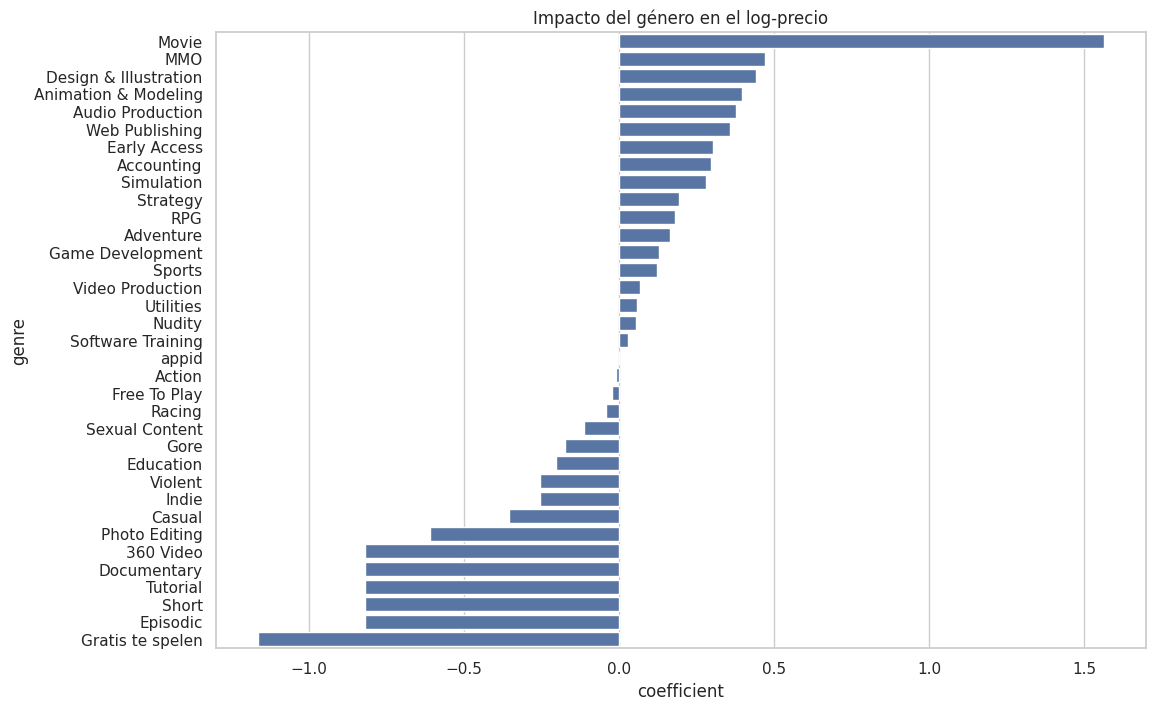

In [319]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=coefficients,
    y="genre",
    x="coefficient"
)

plt.title("Impacto del género en el log-precio")
plt.show()

## Residual analysis

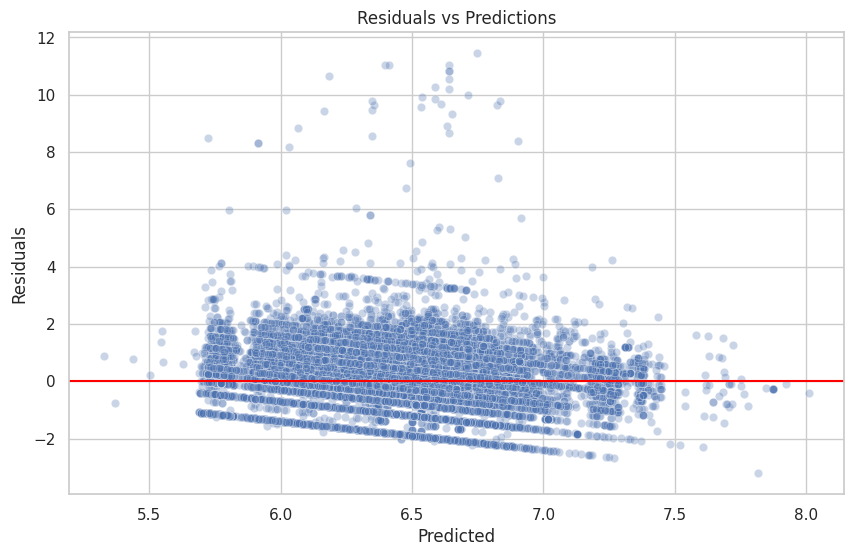

In [320]:
residuals = y_test - preds

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=preds,
    y=residuals,
    alpha=0.3
)

plt.axhline(0, color="red")

plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()